# Getting Started with Image Processing with Python.

## Introduction to Python Imaging Library(PIL)

### Exercise - 1:

#### Read and display the image.

In [40]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

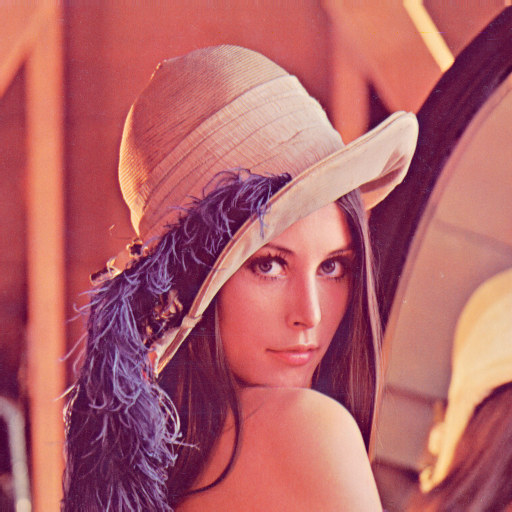

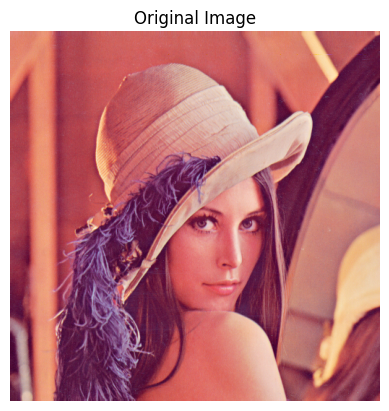

In [41]:
# Read the image
image = Image.open("lena.png")  
# Display using PIL
display(image)

# Display using matplotlib
plt.imshow(image)
plt.axis('off')  # Hide axes
plt.title("Original Image")
plt.show()

#### Display only the top left corner of 100x100 pixels.

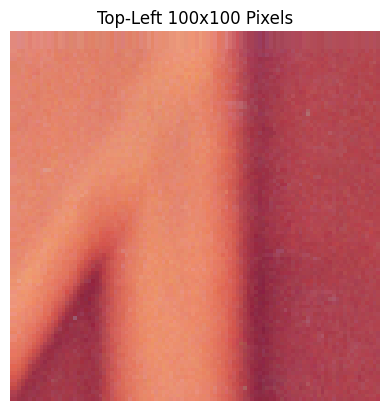

In [42]:
# Ensure image is RGB
image = image.convert('RGB')  # Converts grayscale to RGB if needed
image_array = np.array(image)

# Extract top-left 100x100 pixels
top_left = image_array[:100, :100, :]

# Display the top-left corner
plt.imshow(top_left)
plt.axis('off')
plt.title("Top-Left 100x100 Pixels")
plt.show()

#### Show the three color channels (R, G, B).

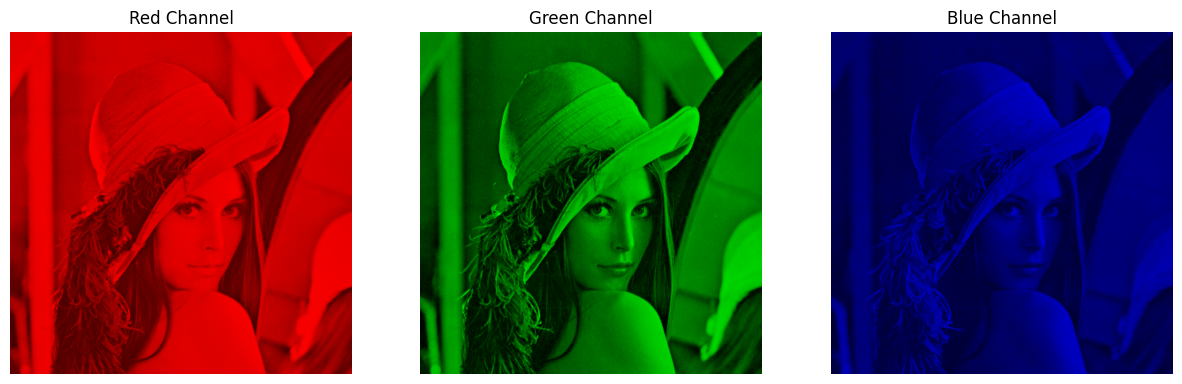

In [43]:
# Ensure the image is in RGB mode
image_array = np.array(image)

# Extract individual color channels
R = image_array.copy()
G = image_array.copy()
B = image_array.copy()

# Zero out other channels
R[:, :, 1] = 0  # Zero out Green
R[:, :, 2] = 0  # Zero out Blue

G[:, :, 0] = 0  # Zero out Red
G[:, :, 2] = 0  # Zero out Blue

B[:, :, 0] = 0  # Zero out Red
B[:, :, 1] = 0  # Zero out Green

# Display each channel
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(R)
axes[0].set_title("Red Channel")
axes[0].axis('off')

axes[1].imshow(G)
axes[1].set_title("Green Channel")
axes[1].axis('off')

axes[2].imshow(B)
axes[2].set_title("Blue Channel")
axes[2].axis('off')

plt.show()

#### Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:

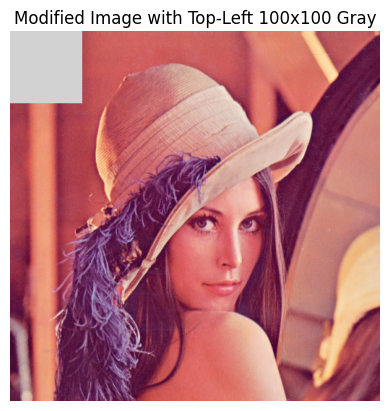

In [44]:
# Modify top-left 100x100 pixels
modified_image = image_array.copy()
modified_image[:100, :100, :] = 210  # Set all channels to 210 (light gray)

# Convert back to PIL image and display
modified_pil = Image.fromarray(modified_image)
plt.imshow(modified_pil)
plt.axis('off')
plt.title("Modified Image with Top-Left 100x100 Gray")
plt.show()

### Exercise - 2:

#### Load and display a grayscale image.

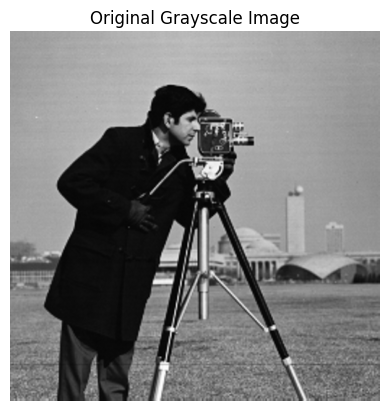

In [45]:
# Load the grayscale image
image = Image.open("cameraman.png").convert('L')  # 'L' mode ensures grayscale

# Convert to NumPy array
image_array = np.array(image)

# Display using matplotlib
plt.imshow(image_array, cmap='gray')
plt.axis('off')
plt.title("Original Grayscale Image")
plt.show()

#### Extract and display the middle section of the image (150 pixels).

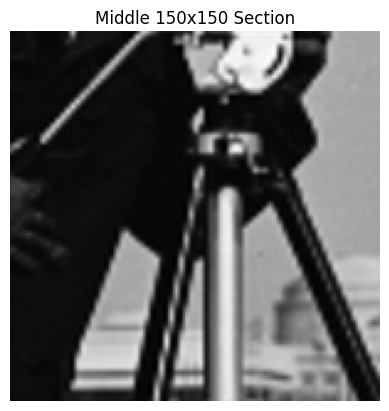

In [46]:
# Image dimensions
height, width = image_array.shape

# Compute start and end indices for center crop
center_row = height // 2
center_col = width // 2
half_size = 150 // 2

# Crop the middle section
middle_section = image_array[center_row - half_size:center_row + half_size,
                             center_col - half_size:center_col + half_size]

# Display the cropped section
plt.imshow(middle_section, cmap='gray')
plt.axis('off')
plt.title("Middle 150x150 Section")
plt.show()

#### Apply a simple threshold to the image

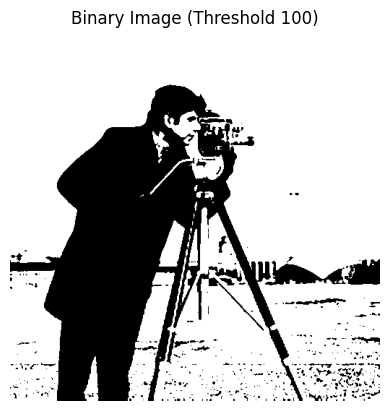

In [47]:
# Apply threshold: pixels < 100 -> 0, pixels >= 100 -> 255
binary_image = np.where(image_array < 100, 0, 255)

# Display binary image
plt.imshow(binary_image, cmap='gray')
plt.axis('off')
plt.title("Binary Image (Threshold 100)")
plt.show()

#### Rotate the image 90 degrees clockwise and display the result.

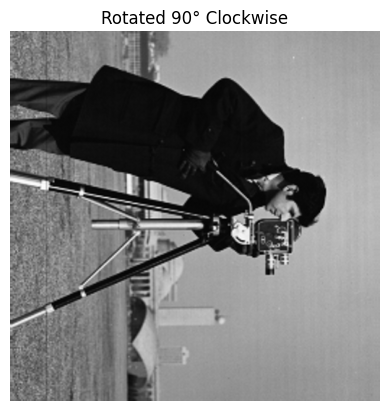

In [48]:
rotated_image = image.rotate(-90, expand=True)  # -90 for clockwise rotation
rotated_array = np.array(rotated_image)

plt.imshow(rotated_array, cmap='gray')
plt.axis('off')
plt.title("Rotated 90° Clockwise")
plt.show()

#### Convert the grayscale image to an RGB image.

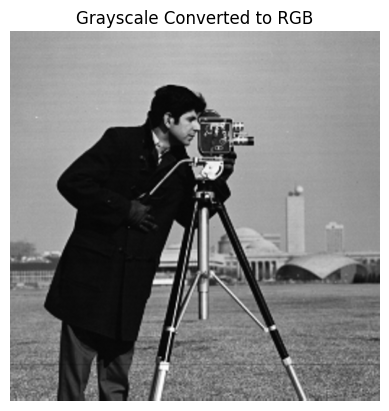

In [49]:
# Convert grayscale array to RGB by stacking the grayscale values
rgb_image_array = np.stack((image_array,)*3, axis=-1)  # shape (H, W, 3)

# Display the RGB image
plt.imshow(rgb_image_array)
plt.axis('off')
plt.title("Grayscale Converted to RGB")
plt.show()

## Image Compression and Decompression using PCA.

### Exercise - 1:

#### Load and Prepare Data:

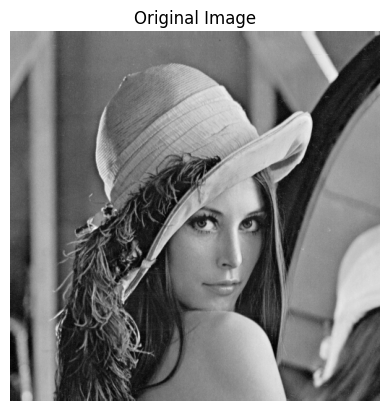

Covariance matrix shape: (512, 512)


In [50]:
# Load the image (convert to grayscale)
image = Image.open("lena_gray.gif").convert('L')  # 'L' for grayscale
image_array = np.array(image, dtype=float)  # Convert to float for calculations

# Display the original image
plt.imshow(image_array, cmap='gray')
plt.axis('off')
plt.title("Original Image")
plt.show()

# Flatten the image into a 2D matrix: each row = one observation (pixel row)
X = image_array

# Standardize (center the data: subtract mean of each column)
mean_X = np.mean(X, axis=0)
X_centered = X - mean_X

# Compute covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

print("Covariance matrix shape:", cov_matrix.shape)

#### Eigen Decomposition and Identifying Principal Components:

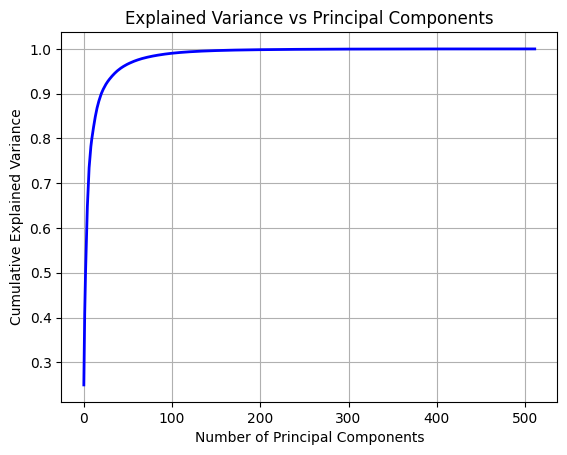

In [51]:
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # eigh for symmetric matrix

# Sort eigenvalues in descending order
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

# Compute explained variance
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot cumulative explained variance
plt.plot(cumulative_variance, color='blue', linestyle='-', linewidth=2)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs Principal Components")
plt.grid()
plt.show()

#### Reconstruction and Experiment:

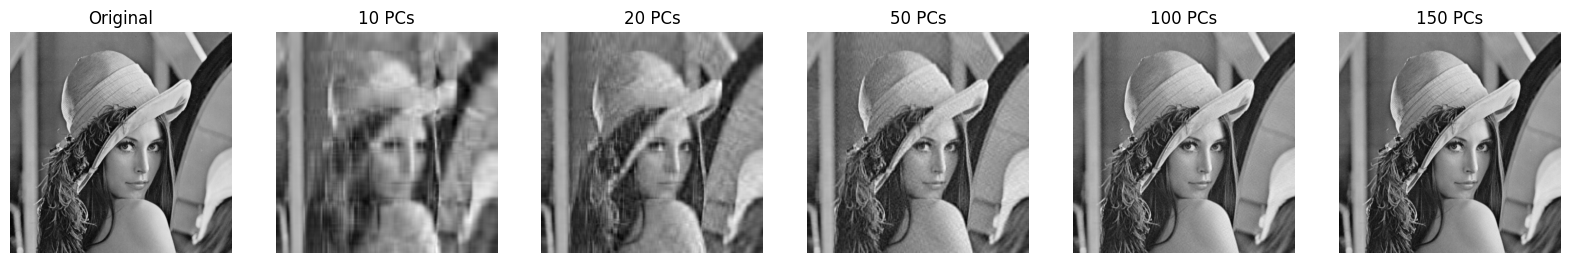

In [52]:
# Choose four different numbers of PCs for experiments
k_values = [10, 20, 50, 100, 150]  # Example, adjust based on image size

fig, axes = plt.subplots(1, 6, figsize=(20, 5))
axes[0].imshow(image_array, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

for i, k in enumerate(k_values):
    # Select top k eigenvectors
    eigenvectors_k = eigenvectors[:, :k]

    # Transform data to lower dimension
    X_reduced = np.dot(X_centered, eigenvectors_k)

    # Reconstruct the image
    X_reconstructed = np.dot(X_reduced, eigenvectors_k.T) + mean_X

    axes[i+1].imshow(X_reconstructed, cmap='gray')
    axes[i+1].set_title(f"{k} PCs")
    axes[i+1].axis('off')

plt.show()